K FOLD CROSS VALIDATION MODEL

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [3]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

<Figure size 640x480 with 0 Axes>

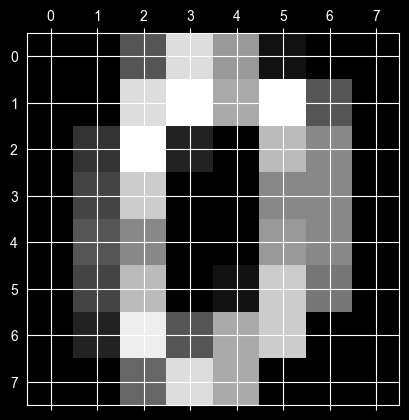

In [4]:
plt.gray()
for i in range(1):
    plt.matshow(digits.images[i])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target,test_size=0.3)

In [6]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9611111111111111

In [7]:
svm = SVC()
svm.fit(X_train, y_train)
svm.score(X_test, y_test)

0.9722222222222222

In [13]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.9703703703703703

In [15]:
kf = KFold(n_splits=3)
kf.get_n_splits(X_train)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [17]:
for train_index, test_index in kf.split([1,2,3,4,5,6,7,8,9]):
    print(train_index, test_index)

[3 4 5 6 7 8] [0 1 2]
[0 1 2 6 7 8] [3 4 5]
[0 1 2 3 4 5] [6 7 8]


In [18]:
def get_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    return score

In [19]:
a = get_score(lr, X_train, X_test, y_train, y_test)
b = get_score(svm, X_train, X_test, y_train, y_test)
c = get_score(rf, X_train, X_test, y_train, y_test)
print(a, b, c)

C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9611111111111111 0.9722222222222222 0.9537037037037037


In [20]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=3)

In [23]:
scores_l = []
scores_svm = []
scores_rf = []
for train_index, test_index in skf.split(digits.data, digits.target):
    X_train, X_test, y_train, y_test = digits.data[train_index], digits.data[test_index], digits.target[train_index], digits.target[test_index]

In [25]:
e = (get_score(lr, X_train, X_test, y_train, y_test))
f = (get_score(svm, X_train, X_test, y_train, y_test))
g = (get_score(rf, X_train, X_test, y_train, y_test))
print(e,f,g)

C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9165275459098498 0.9649415692821369 0.9198664440734557


In [29]:
h = scores_l.append((get_score(lr, X_train, X_test, y_train, y_test)))
j = scores_svm.append((get_score(svm, X_train, X_test, y_train, y_test)))
k = scores_rf.append((get_score(rf, X_train, X_test, y_train, y_test)))

C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


None None None


In [31]:
print(scores_l, scores_svm, scores_rf)

[0.9165275459098498, 0.9165275459098498, 0.9165275459098498, 0.9165275459098498] [0.9649415692821369, 0.9649415692821369, 0.9649415692821369, 0.9649415692821369] [0.9198664440734557, 0.9198664440734557, 0.9282136894824707]


In [33]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(lr, digits.data, digits.target, cv=3))
print(cross_val_score(svm, digits.data, digits.target, cv=3))
print(cross_val_score(rf, digits.data, digits.target, cv=3))

C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\amitd\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

[0.92153589 0.94156928 0.91652755]
[0.96494157 0.97996661 0.96494157]
[0.93155259 0.95659432 0.92821369]
